In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../../src')
from data_loader import DataLoader
from noise_optimizers import CKF_NoiseOptimizer

%matplotlib inline
np.random.seed(777)

## Load data

In [10]:
kitti_root_dir = '../../../data'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0016'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [11]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/ckf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/ckf'

In [12]:
ckf_optimizer = CKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [13]:
ckf_optimizer.compare(load_exported=True)

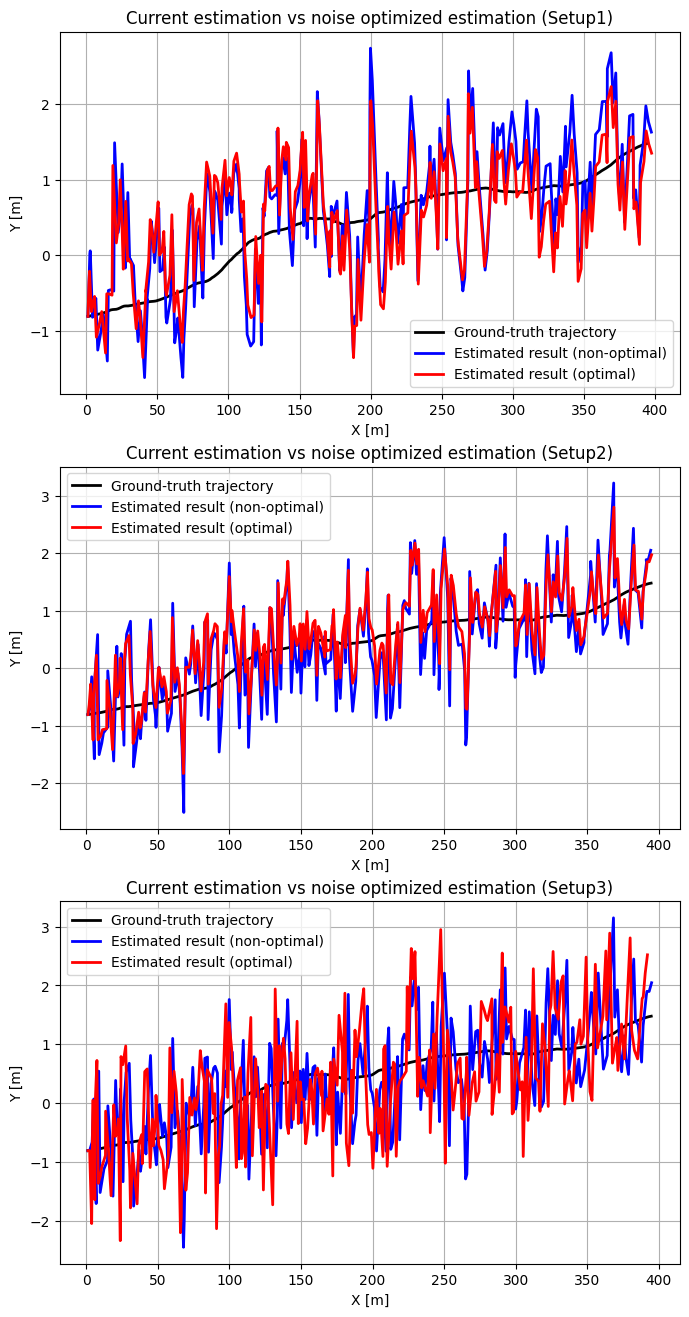

In [14]:
ckf_optimizer.visualize_results()

In [15]:
ckf_optimizer.error_df

Setups        Setup1(IMU+VO)               Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE    MAX                MAE   RMSE    MAX   
Non-optimized          0.764  0.968  3.326              0.589  0.740  2.182   
Optimized              0.714  0.942  3.334              0.517  0.667  2.595   
∆                     -0.050 -0.026  0.008             -0.072 -0.073  0.413   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       0.497  0.631  2.122  
Optimized           1.348  1.603  3.726  
∆                   0.851  0.972  1.604

## Conclusion

In this notebook, the noise optimization technique, Nelder-Mead algorithm, is applied to the Cubature Kalman Filter.

The results show that the noise optimization was not working correctly, where the optimizer never converged in the setup 1, resulting in the experiencing large error in the trajectory. In terms of the setup2, although the optimizer converges, the performance is worse than the current implementation.

However, a performance improvement was observed in the setup 3 by decreasing all the given metrices indicating that the noise vectors, including process noise and measuremnt noise for VO and GPS, are optimized by the given algorithm.